In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import pymc as pm
import arviz as az
import arviz_plots as azp
from sklearn.preprocessing import StandardScaler
import glob
import os
import re
import difflib
from sklearn.preprocessing import StandardScaler
pd.set_option('display.max_columns', None)

g++ not available, if using conda: `conda install gxx`


In [2]:
#reading in our data
lanes_gdf = gpd.read_file("Data/Bicycle_Lanes.geojson").to_crs(epsg=32618)
blocks_gdf = gpd.read_file("Data/Census_Blocks_in_2020.geojson").to_crs(epsg=32618)
stations_gdf = gpd.read_file("Data/Capital_Bike_Share_Locations.geojson").to_crs(epsg=32618)

In [3]:
stations_gdf.head()

,NAME,STATION_TYPE,STATION_ID,STATION_STATUS,LAST_REPORTED,NUM_DOCKS_AVAILABLE,NUM_DOCKS_DISABLED,NUM_BIKES_AVAILABLE,NUM_EBIKES_AVAILABLE,NUM_BIKES_DISABLED,IS_INSTALLED,IS_RETURNING,IS_RENTING,HAS_KIOSK,IOS,ANDROID,ELECTRIC_BIKE_SURCHARGE_WAIVER,EIGHTD_HAS_KEY_DISPENSER,CAPACITY,RENTAL_METHODS,REGION_ID,REGION_NAME,GIS_ID,LATITUDE,LONGITUDE,GIS_LAST_MOD_DTTM,OBJECTID,geometry
0,Tyco Rd & Boyd Pointe Way,classic,1890899353648060422,None,2026-06-25 02:39:36+00:00,1,0,11,0,0,YES,YES,YES,YES,https://dc.lft.to/lastmile_qr_scan,https://dc.lft.to/lastmile_qr_scan,NO,NO,12,"KEY,CREDITCARD",NaN,DCA-CABI,None,38.930767,-77.241436,2026-06-25 02:42:17+00:00,358320298,POINT (305710.432 4311483.001)
1,New Mexico & Cathedral Ave NW,classic,1884993950171398452,None,2026-06-25 02:39:49+00:00,2,0,17,8,0,YES,YES,YES,YES,https://dc.lft.to/lastmile_qr_scan,https://dc.lft.to/lastmile_qr_scan,NO,NO,19,"KEY,CREDITCARD",NaN,DCA-CABI,None,38.930316,-77.083704,2026-06-25 02:42:18+00:00,358320299,POINT (319382.648 4311108.912)
2,33rd St & Wisconsin Ave NW,classic,1926924117062925284,None,2026-06-25 02:39:56+00:00,14,0,2,0,3,YES,YES,YES,YES,https://dc.lft.to/lastmile_qr_scan,https://dc.lft.to/lastmile_qr_scan,NO,NO,19,"KEY,CREDITCARD",NaN,DCA-CABI,None,38.912181,-77.066074,2026-06-25 02:42:18+00:00,358320300,POINT (320865.174 4309061.803)
3,Kingsbridge Dr & Draper Dr,classic,1892762694406615240,None,2026-06-25 02:40:11+00:00,4,0,7,0,0,YES,YES,YES,YES,https://dc.lft.to/lastmile_qr_scan,https://dc.lft.to/lastmile_qr_scan,NO,NO,11,"KEY,CREDITCARD",NaN,DCA-CABI,None,38.868545,-77.282083,2026-06-25 02:42:18+00:00,358320301,POINT (302013.593 4304664.569)
4,South St & University Dr,classic,1877158937567185816,None,2026-06-25 02:40:07+00:00,9,0,3,0,0,YES,YES,YES,YES,https://dc.lft.to/lastmile_qr_scan,https://dc.lft.to/lastmile_qr_scan,NO,NO,12,"KEY,CREDITCARD",NaN,DCA-CABI,None,38.844249,-77.305336,2026-06-25 02:42:18+00:00,358320302,POINT (299927.868 4302019.249)


In [4]:
blocks_gdf.head()

,BLKGRP,BLOCK,GEOID,P0010001,P0010002,P0010003,P0010004,P0010005,P0010006,P0010007,P0010008,P0020002,P0020005,P0020006,P0020007,P0020008,P0020009,P0020010,P0030001,P0030003,P0030004,P0030005,P0030006,P0030007,P0030008,P0040002,P0040005,P0040006,P0040007,P0040008,P0040009,P0040010,H0010001,H0010002,H0010003,TRACT,ALAND,AWATER,SHAPE_LENG,STUSAB,SUMLEV,GEOCODE,STATE,NAME,POP100,HU100,P0010009,P0010010,P0010011,P0010012,P0010013,P0010014,P0010015,P0010016,P0010017,P0010018,P0010019,P0010020,P0010021,P0010022,P0010023,P0010024,P0010025,P0010026,P0010027,P0010028,P0010029,P0010030,P0010031,P0010032,P0010033,P0010034,P0010035,P0010036,P0010037,P0010038,P0010039,P0010040,P0010041,P0010042,P0010043,P0010044,P0010045,P0010046,P0010047,P0010048,P0010049,P0010050,P0010051,P0010052,P0010053,P0010054,P0010055,P0010056,P0010057,P0010058,P0010059,P0010060,P0010061,P0010062,P0010063,P0010064,P0010065,P0010066,P0010067,P0010068,P0010069,P0010070,P0010071,P0020001,P0020003,P0020004,P0020011,P0020012,P0020013,P0020014,P0020015,P0020016,P0020017,P0020018,P0020019,P0020020,P0020021,P0020022,P0020023,P0020024,P0020025,P0020026,P0020027,P0020028,P0020029,P0020030,P0020031,P0020032,P0020033,P0020034,P0020035,P0020036,P0020037,P0020038,P0020039,P0020040,P0020041,P0020042,P0020043,P0020044,P0020045,P0020046,P0020047,P0020048,P0020049,P0020050,P0020051,P0020052,P0020053,P0020054,P0020055,P0020056,P0020057,P0020058,P0020059,P0020060,P0020061,P0020062,P0020063,P0020064,P0020065,P0020066,P0020067,P0020068,P0020069,P0020070,P0020071,P0020072,P0020073,P0030002,P0030009,P0030010,P0030011,P0030012,P0030013,P0030014,P0030015,P0030016,P0030017,P0030018,P0030019,P0030020,P0030021,P0030022,P0030023,P0030024,P0030025,P0030026,P0030027,P0030028,P0030029,P0030030,P0030031,P0030032,P0030033,P0030034,P0030035,P0030036,P0030037,P0030038,P0030039,P0030040,P0030041,P0030042,P0030043,P0030044,P0030045,P0030046,P0030047,P0030048,P0030049,P0030050,P0030051,P0030052,P0030053,P0030054,P0030055,P0030056,P0030057,P0030058,P0030059,P0030060,P0030061,P0030062,P0030063,P0030064,P0030065,P0030066,P0030067,P0030068,P0030069,P0030070,P0030071,P0040001,P0040003,P0040004,P0040011,P0040012,P0040013,P0040014,P0040015,P0040016,P0040017,P0040018,P0040019,P0040020,P0040021,P0040022,P0040023,P0040024,P0040025,P0040026,P0040027,P0040028,P0040029,P0040030,P0040031,P0040032,P0040033,P0040034,P0040035,P0040036,P0040037,P0040038,P0040039,P0040040,P0040041,P0040042,P0040043,P0040044,P0040045,P0040046,P0040047,P0040048,P0040049,P0040050,P0040051,P0040052,P0040053,P0040054,P0040055,P0040056,P0040057,P0040058,P0040059,P0040060,P0040061,P0040062,P0040063,P0040064,P0040065,P0040066,P0040067,P0040068,P0040069,P0040070,P0040071,P0040072,P0040073,P0050001,P0050002,P0050003,P0050004,P0050005,P0050006,P0050007,P0050008,P0050009,P0050010,OBJECTID,SHAPEAREA,SHAPELEN,geometry
0,1,1004,7500000US110010001021004,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,000102,125930,0,1857.054502,DC,750,110010001021004,11,Block 1004,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,"POLYGON ((320658.026 4309604.397, 320645.469 4..."
1,1,1006,7500000US110010001021006,265,244,210,6,0,13,0,15,46,195,6,0,13,0,0,240,190,6,0,13,0,15,39,178,6,0,13,0,0,201,189,12,000102,162560,0,2139.237670,DC,750,110010001021006,11,Block 1006,265,201,21,20,0,0,2,0,17,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,265,219,214,5,4,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,

In [3]:
#load in our 2017 pre-bike lane boom data from folder
folder_path = r"Data\2017-capitalbikeshare-tripdata"
all_files = glob.glob(os.path.join(folder_path, "*.csv"))
df_list = [pd.read_csv(f) for f in all_files]
trips_df = pd.concat(df_list, ignore_index=True)


In [4]:
#Getting our station level total volumes 
starts = trips_df.groupby('Start station').size().reset_index(name='trip_starts')
ends = trips_df.groupby('End station').size().reset_index(name='trip_ends')
station_volume = pd.merge(starts, ends, left_on='Start station', right_on='End station', how='outer')
station_volume['total_volume'] = station_volume['trip_starts'].fillna(0) + station_volume['trip_ends'].fillna(0)
station_volume['STATION_NAME_RAW'] = station_volume['Start station'].combine_first(station_volume['End station'])


#some additional work to clean up station names
#One issue I faced was changing station IDs utilized in the station location list vs
def standardize_dc_intersections(name_series):
    s = name_series.str.lower()
    s = s.str.replace('&', 'and', regex=False).str.replace('/', 'and', regex=False)
    s = s.str.replace(r'[^\w\s]', ' ', regex=True)
    # Strip common DC street suffixes and quadrants
    stop_words = r'\b(st|ave|rd|pl|blvd|dr|sq|cir|nw|ne|se|sw)\b'
    s = s.str.replace(stop_words, '', regex=True)
    return s.str.replace(r'\s+', ' ', regex=True).str.strip()

#applying our cleaner 
station_volume['STATION_NAME_CLEAN'] = standardize_dc_intersections(station_volume['STATION_NAME_RAW'])
stations_gdf['NAME_CLEAN'] = standardize_dc_intersections(stations_gdf['NAME']) #[cite: 3]
valid_2026_names = stations_gdf['NAME_CLEAN'].tolist()

#not lookign for exact matches but close enough... 
def get_best_match(name):
    match = difflib.get_close_matches(name, valid_2026_names, n=1, cutoff=0.85)
    return match[0] if match else name

exact_match_mask = station_volume['STATION_NAME_CLEAN'].isin(valid_2026_names)
unmatched_names = station_volume.loc[~exact_match_mask, 'STATION_NAME_CLEAN']
station_volume.loc[~exact_match_mask, 'STATION_NAME_CLEAN'] = unmatched_names.apply(get_best_match)


#small diagnostics to see how many stations we were able to match 
final_match_mask = station_volume['STATION_NAME_CLEAN'].isin(valid_2026_names)
total_stations = len(station_volume)
matched_count = final_match_mask.sum()
unmatched_count = total_stations - matched_count

print(f"--- FINAL MERGE DIAGNOSTICS ---")
print(f"Total 2017 Stations: {total_stations}")
print(f"Successfully Matched: {matched_count}")
print(f"Failed to Match: {unmatched_count} ({(unmatched_count/total_stations)*100:.1f}%)")

if unmatched_count > 0:
    print("\nSample of permanently lost 2017 stations (likely relocated/removed):")
    lost_samples = station_volume[~final_match_mask]['STATION_NAME_RAW'].head(5)
    for name in lost_samples:
        print(f" - {name}")
print(f"-------------------------------\n")

#merge our stations with volume into our stations geodataframe for analysis 
stations_with_vol = stations_gdf.merge(
    station_volume, 
    left_on='NAME_CLEAN', 
    right_on='STATION_NAME_CLEAN', 
    how='inner'
)

--- FINAL MERGE DIAGNOSTICS ---
Total 2017 Stations: 487
Successfully Matched: 410
Failed to Match: 77 (15.8%)

Sample of permanently lost 2017 stations (likely relocated/removed):
 - 12th & Army Navy Dr
 - 14th & D St NW / Ronald Reagan Building
 - 15th & Crystal Dr
 - 15th St & Pennsylvania Ave NW/Pershing Park
 - 18th & Eads St.
-------------------------------



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_T, beta_Z]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.


             mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
beta_T     0.2235   0.034     0.17     0.28      7484      5658  1.00   
beta_Z[0]   0.206  0.0419     0.14     0.27      6900      5857  1.00   

          mcse_mean  mcse_sd  
beta_T      0.00039  0.00028  
beta_Z[0]    0.0005  0.00035  


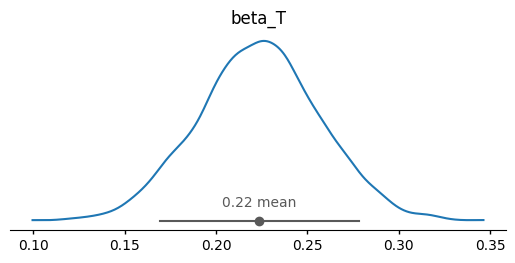

In [ ]:
# ==========================================
# 4. AGGREGATE TREATMENT (T) & OUTCOME (Y)
# ==========================================
# Treatment: Spatially join matched stations into Census Blocks and sum demand

#treatment 
stations_in_blocks = gpd.sjoin(stations_with_vol, blocks_gdf, how="inner", predicate="intersects")
t_agg = stations_in_blocks.groupby('GEOID').agg(T_historical_volume=('total_volume', 'sum')).reset_index()

#our outcome we are looking for --> bike lanes, protected or dual protected 
protected_lanes = lanes_gdf[
    (lanes_gdf['BIKELANE_PROTECTED'].notna()) |
    (lanes_gdf['BIKELANE_DUAL_PROTECTED'].notna())
]
#Clip lanes to blocks and sum meterage
lanes_clipped = gpd.overlay(protected_lanes, blocks_gdf, how="intersection")
lanes_clipped['length_m'] = lanes_clipped.geometry.length
y_agg = lanes_clipped.groupby('GEOID').agg(protected_length=('length_m', 'sum')).reset_index()



#building our casual dataframe... 
df = pd.DataFrame(blocks_gdf[['GEOID', 'P0010001']])
df.rename(columns={'P0010001': 'Z_population'}, inplace=True)

df = df.merge(t_agg, on='GEOID', how='left').fillna({'T_historical_volume': 0})
df = df.merge(y_agg, on='GEOID', how='left').fillna({'protected_length': 0})
df['Y_has_lane'] = (df['protected_length'] > 50).astype(int)


#drop missing covariates and standardize for PyMC - just looking at population for now, but could add more covariates later
covariates = ['Z_population']
df = df.dropna(subset=covariates + ['T_historical_volume'])

scaler = StandardScaler()
X_T = scaler.fit_transform(df[['T_historical_volume']])
X_Z = scaler.fit_transform(df[covariates])
Y_obs = df['Y_has_lane'].values


#Bayesian casual model now 
#using PyMC 
with pm.Model() as causal_model:
    alpha = pm.Normal('alpha', mu=0, sigma=1.5)
    
    #Effect of historical demand
    beta_T = pm.Normal('beta_T', mu=0, sigma=1.5)  

    #Effect of covariates (e.g., population)
    beta_Z = pm.Normal('beta_Z', mu=0, sigma=1.5, shape=1) 
    
    #logit link function to model the probability of having a bike lane
    mu = alpha + beta_T * X_T[:, 0] + pm.math.dot(X_Z, beta_Z)
    p = pm.Deterministic('p', pm.math.invlogit(mu))
    
    #Bernoulli likelihood for the binary outcome - bike lane yes or no
    Y_est = pm.Bernoulli('Y_est', p=p, observed=Y_obs)
    
    #Sample the posterior distribution using MCMC
    trace = pm.sample(draws=2000, tune=1000, target_accept=0.9, return_inferencedata=True, random_seed=42)

#let's check our results....
summary = az.summary(trace, var_names=['beta_T', 'beta_Z'])
print(summary)

#Use plot_dist to visualize it 
azp.plot_dist(trace, var_names=['beta_T'])